# Stock Price Movement Predictor

GCSRM 2026 Technical Track — AI & Machine Learning, Option A.

**Status: Phase 1 (project foundation).** This notebook currently contains structure only — no data has been loaded, no model has been trained, and no results are reported yet. Every section below will be filled in during its corresponding implementation phase.

## 1. Problem Statement

Predict whether tomorrow's closing price for a liquid equity/index will be **higher (Up)** or **lower (Down)** than today's closing price, using only information available as of today's close. This is framed as binary classification, not price regression.

_To be completed further in later phases as the approach is finalized._

## 2. Objective

- Build a leak-free, chronologically-evaluated next-day direction classifier.
- Compare it honestly against a persistence baseline, a majority-class baseline, and a raw-feature model.
- Demonstrate zero forward/temporal leakage at every step.

_To be completed._

## 3. Dataset

- **Symbol:** SPY (SPDR S&P 500 ETF Trust)
- **Source:** Yahoo Finance via the `yfinance` package
- **Frequency:** Daily OHLCV
- **Date range:** defined in `config.py` (`START_DATE` / `END_DATE`)
- **Adjustment:** fetched with `auto_adjust=False` to keep raw, as-quoted OHLC prices (Yahoo's adjusted close retroactively rewrites history when new dividends/splits are recorded, which this project's leakage-prevention plan intentionally avoids)

Rationale for this choice is documented in `README.md` and the Phase 0 design notes: SPY is highly liquid, has a long continuous daily history, and avoids single-company idiosyncrasies (earnings surprises, splits, delistings) that would inject label noise unrelated to general market technicals.

Actual row counts and date coverage are printed by the Data Loading cell below -- real numbers, not estimated in advance.

## 4. Data Loading

Implemented via `src/data_loader.py`. Fetches real daily OHLCV data for the configured symbol/date range (or reuses a cached copy whose coverage already matches the configuration) and caches it to `data/raw/SPY.csv`. No synthetic, sampled, or manually-typed data is used anywhere in this project.

In [1]:
# Phase 2: load configuration and (eventually) cached OHLCV data.
#
# Search upward from the current working directory for config.py rather than
# assuming a fixed relative path -- Jupyter's starting working directory
# depends on how the notebook is launched (interactively vs. headless
# execution), and a fixed ".." guess can silently resolve to the wrong
# directory on someone else's machine.
import sys
from pathlib import Path

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config.py").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root (config.py not found).")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

config.ensure_output_directories()
print(f"Project root: {PROJECT_ROOT}")
print(f"Symbol: {config.SYMBOL}")
print(f"Data source: {config.DATA_SOURCE}")
print(f"Start date: {config.START_DATE}")
print(f"Random seed: {config.RANDOM_SEED}")

Project root: C:\Users\ayush\OneDrive\Desktop\Stock Time Movement Predictor
Symbol: SPY
Data source: yfinance
Start date: 2005-01-01
Random seed: 42


In [2]:
from src.data_loader import load_or_fetch_ohlcv

df = load_or_fetch_ohlcv(
    config.SYMBOL,
    config.START_DATE,
    config.END_DATE,
    config.RAW_DATA_FILE,
)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print("Dtypes:")
print(df.dtypes)
print()
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print()
print("First 5 rows:")
display(df.head())
print()
print("Last 5 rows:")
display(df.tail())

Using cached data at C:\Users\ayush\OneDrive\Desktop\Stock Time Movement Predictor\data\raw\SPY.csv (5457 rows, 2005-01-03 to 2026-09-11).
Shape: (5457, 6)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Dtypes:
Date      datetime64[us]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

Date range: 2005-01-03 to 2026-09-11

First 5 rows:


,Date,Open,High,Low,Close,Volume
0,2005-01-03,121.559998,121.760002,119.900002,120.300003,55748000
1,2005-01-04,120.459999,120.540001,118.440002,118.830002,69167600
2,2005-01-05,118.739998,119.250000,118.000000,118.010002,65667300
3,2005-01-06,118.440002,119.150002,118.260002,118.610001,47814700
4,2005-01-07,118.970001,119.230003,118.129997,118.440002,55847700



Last 5 rows:


,Date,Open,High,Low,Close,Volume
5452,2026-09-04,772.010010,772.869995,769.000000,770.190002,34054200
5453,2026-09-08,769.070007,769.700012,765.140015,765.960022,44746100
5454,2026-09-09,764.080017,764.469971,760.940002,762.400024,32812400
5455,2026-09-10,758.030029,760.109985,756.640015,757.830017,42740400
5456,2026-09-11,764.719971,766.380005,763.599976,764.289978,45477300


## 5. Data Validation

Runs structural and sanity checks on the downloaded dataset via `src.data_loader.validate_ohlcv` -- required columns, chronological ordering, duplicate dates, missing/infinite values, OHLC relationship sanity (High >= Low, Open/Close within [Low, High]), and non-negative volume. Every number below comes from the real downloaded dataset; zero problems found is reported explicitly rather than assumed.

In [3]:
from src.data_loader import validate_ohlcv, print_validation_report

report = validate_ohlcv(df, config.START_DATE, config.END_DATE)
print_validation_report(report)

=== Data Validation Report ===
Dataset shape: (5457, 6)
Number of rows: 5457
Number of columns: 6
First date: 2005-01-03 00:00:00
Last date: 2026-09-11 00:00:00
Required columns present: True
Dates valid (no nulls): True
Chronologically sorted: True
Duplicate dates: 0
Numeric dtypes OK: True
Missing values (total): 0
Missing values by column: {'Date': 0, 'Open': 0, 'High': 0, 'Low': 0, 'Close': 0, 'Volume': 0}
Infinite values (total): 0
Invalid High < Low rows: 0
Invalid Open-out-of-[Low,High] rows: 0
Invalid Close-out-of-[Low,High] rows: 0
Negative volume rows: 0
Covers requested start date: True


In [4]:
# Self-verifying checks -- these actually run against the real dataset above.
# If any assertion fails, the notebook stops here rather than silently
# continuing with bad data.
assert report["has_all_required_columns"], "Missing required OHLCV columns."
assert report["dates_valid"], "Some dates are null/invalid."
assert report["is_chronological"], "Data is not sorted chronologically (oldest to newest)."
assert report["duplicate_dates"] == 0, "Duplicate dates remain in the dataset."
assert report["numeric_dtypes_ok"], "OHLCV columns are not all numeric."
assert report["missing_values_total"] == 0, "Missing values found in OHLCV data."
assert report["infinite_values_total"] == 0, "Infinite values found in OHLCV data."
assert report["invalid_ohlc_relationship_rows"] == 0, "Invalid OHLC relationships found (High<Low or Open/Close outside [Low,High])."
assert report["negative_volume_rows"] == 0, "Negative volume rows found."
print("All Phase 2 validation checks passed on the real downloaded dataset.")

All Phase 2 validation checks passed on the real downloaded dataset.


### Dataset Exploration: Closing Price Over Time

A quick visual sanity check of the raw series before any feature engineering happens in later phases.

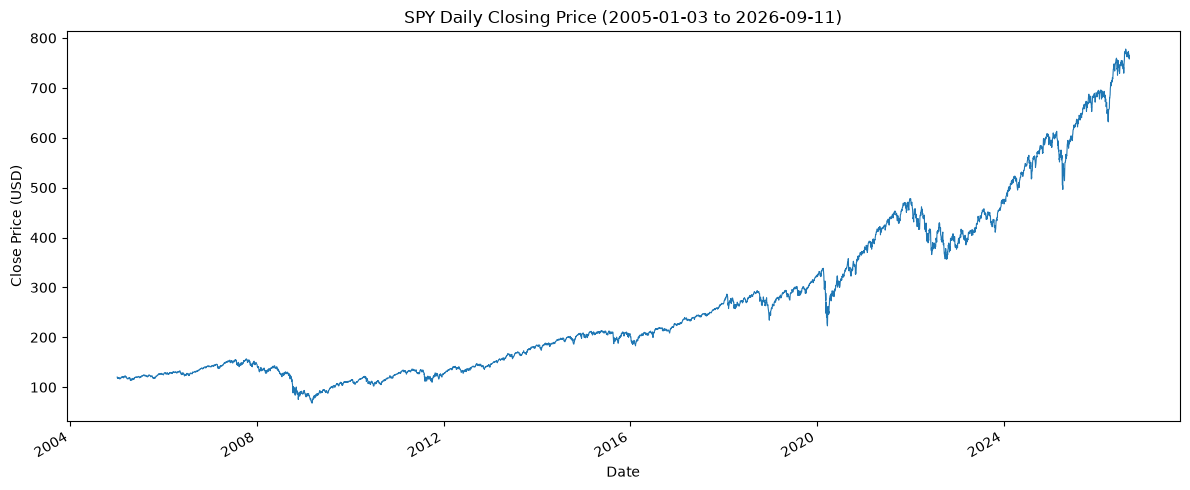

Saved figure to C:\Users\ayush\OneDrive\Desktop\Stock Time Movement Predictor\figures\spy_close_price.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["Close"], linewidth=0.8, color="#1f77b4")
ax.set_title(f"{config.SYMBOL} Daily Closing Price ({df['Date'].min().date()} to {df['Date'].max().date()})")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
fig.autofmt_xdate()
fig.tight_layout()

figure_path = config.FIGURES_DIR / "spy_close_price.png"
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to {figure_path}")

## 6. Target Construction

**Definition.** For trading day `t`:

```
Target[t] = 1   if Close[t+1] >  Close[t]     (UP)
Target[t] = 0   if Close[t+1] <= Close[t]     (DOWN_OR_FLAT)
```

- `Close[t+1]` (tomorrow's close) is used **only** to compute the label for row `t`. It is never added to the returned DataFrame as its own column and must never become a model feature -- see Section 7 for an explicit audit of this.
- **Equal closes are DOWN_OR_FLAT (0), not discarded.** An unchanged price is not a directional "up" move, and silently dropping tie rows would shrink the dataset and bias the class balance based on an arbitrary choice.
- **The final row is dropped.** It has no following trading day, so no real target can be computed for it -- `build_target` removes it rather than fabricating a label.
- Implemented in `src/preprocessing.py::build_target`, which also validates that `Close` exists, is numeric, contains no NaNs, and (when a `Date` column is present) that dates are unique and sorted chronologically before touching anything.

In [6]:
from src.preprocessing import build_target

target_df = build_target(df)

print(f"Input rows (raw OHLCV):  {len(df)}")
print(f"Output rows (with Target): {len(target_df)}  (expected: {len(df) - 1}, i.e. one fewer -- the final unlabeled row was dropped)")
print(f"Columns: {list(target_df.columns)}")
print()
print("Target value counts:")
print(target_df['Target'].value_counts().sort_index())
assert len(target_df) == len(df) - 1
assert set(target_df["Target"].unique()) <= {0, 1}
print()
print("OK: exactly one row was dropped and Target is strictly binary.")

Input rows (raw OHLCV):  5457
Output rows (with Target): 5456  (expected: 5456, i.e. one fewer -- the final unlabeled row was dropped)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target']

Target value counts:
Target
0    2476
1    2980
Name: count, dtype: int64

OK: exactly one row was dropped and Target is strictly binary.


## 7. Leak-Free Verification

At date `t`, the target represents whether the next trading day's Close is higher than today's Close. **The next day's Close is used only to construct the label and is never included as a model feature.**

The table below makes this explicit for human auditing: it shows `Close[t]` (today, a legitimate feature-time value) next to `Close[t+1]` (tomorrow, label-construction only) and the resulting `Target`. The `Close[t+1]` column exists **only in this display** -- it is not part of `target_df` and will never be part of any feature matrix built in later phases.

In [7]:
import pandas as pd

# This verification table is built directly from the raw `df` (not
# `target_df`) purely for display purposes, so the "not a feature" column is
# never at risk of being mistaken for part of the modeling DataFrame.
verification_df = pd.DataFrame(
    {
        "Date": df["Date"].iloc[:-1].values,
        "Close_t": df["Close"].iloc[:-1].values,
        "Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE": df["Close"].iloc[1:].values,
        "Target": target_df["Target"].values,
    }
)

print("Date | Close[t] | Close[t+1] (USED ONLY FOR LABEL CONSTRUCTION -- NOT A MODEL FEATURE) | Target")
display(verification_df.head(10))
print("...")
display(verification_df.tail(10))

# Manually obvious check: Target must equal 1 exactly where Close[t+1] > Close[t].
manual_target = (verification_df["Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE"] > verification_df["Close_t"]).astype(int)
assert (manual_target == verification_df["Target"]).all(), "Target does not match the manual Close[t+1] > Close[t] check."
print()
print("OK: Target matches a manual, independently-recomputed Close[t+1] > Close[t] check on every row.")

Date | Close[t] | Close[t+1] (USED ONLY FOR LABEL CONSTRUCTION -- NOT A MODEL FEATURE) | Target


,Date,Close_t,Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE,Target
0,2005-01-03,120.300003,118.830002,0
1,2005-01-04,118.830002,118.010002,0
2,2005-01-05,118.010002,118.610001,1
3,2005-01-06,118.610001,118.440002,0
4,2005-01-07,118.440002,119.000000,1
5,2005-01-10,119.000000,118.180000,0
6,2005-01-11,118.180000,118.570000,1
7,2005-01-12,118.570000,117.620003,0
8,2005-01-13,117.620003,118.239998,1
9,2005-01-14,118.239998,119.470001,1


...


,Date,Close_t,Close_t_plus_1__LABEL_ONLY_NOT_A_FEATURE,Target
5446,2026-08-27,771.099976,769.349976,0
5447,2026-08-28,769.349976,767.049988,0
5448,2026-08-31,767.049988,761.780029,0
5449,2026-09-01,761.780029,765.159973,1
5450,2026-09-02,765.159973,773.169983,1
5451,2026-09-03,773.169983,770.190002,0
5452,2026-09-04,770.190002,765.960022,0
5453,2026-09-08,765.960022,762.400024,0
5454,2026-09-09,762.400024,757.830017,0
5455,2026-09-10,757.830017,764.289978,1



OK: Target matches a manual, independently-recomputed Close[t+1] > Close[t] check on every row.


### Explicit leakage assertions

Programmatic checks -- not just a visual spot check -- that the target-construction machinery hasn't leaked anything forward. No feature matrix exists yet (that's Phase 6+), so the assertions below establish the ground truth (`target_df`'s own structure) that any future feature matrix will be checked against via `assert_no_target_leakage`.

In [8]:
from src.preprocessing import assert_no_target_leakage

# 1. The only new column added by build_target is "Target" itself -- no
#    temporary future-derived helper column (e.g. a raw Close[t+1] column)
#    survived into the returned DataFrame.
assert list(target_df.columns) == list(df.columns) + ["Target"], "Unexpected helper column(s) remained in target_df."

# 2. The final row without a target does not remain.
assert target_df["Date"].max() < df["Date"].max(), "The final (unlabeled) row was not dropped."
assert len(target_df) == len(df) - 1

# 3. Target is strictly binary.
assert set(target_df["Target"].unique()) <= {0, 1}

# 4. A hypothetical feature-column list is checked against the target column
#    and known future-derived helper names (the real check used once a
#    feature matrix exists in Phase 6+).
assert_no_target_leakage(["Open", "High", "Low", "Close", "Volume"])  # OK: no target, no helper columns
try:
    assert_no_target_leakage(["Open", "Close", "Target"])
    raise RuntimeError("assert_no_target_leakage should have rejected a feature list containing Target.")
except AssertionError:
    pass

print("OK: all explicit leakage assertions passed.")

OK: all explicit leakage assertions passed.


## 8. Class Balance

Reports the distribution of the binary target across the full dataset and across each chronological partition (train/validation/test). The chronological split itself -- exact date ranges, row counts, and the ordering guarantee -- is detailed formally in Section 9 immediately below; it is computed once in the next cell and reused there, so the numbers in both sections come from the same split object.

In [9]:
from src.preprocessing import chronological_split, compute_class_balance, print_class_balance

# Computed here (rather than in Section 9) because per-partition class
# balance needs the split to already exist; Section 9 reuses these same
# train_df/validation_df/test_df objects for its detailed date-range report.
train_df, validation_df, test_df = chronological_split(target_df, config.TRAIN_RATIO, config.VALIDATION_RATIO)

overall_balance = compute_class_balance(target_df["Target"])
print_class_balance(overall_balance, label="full dataset")
print()
train_balance = compute_class_balance(train_df["Target"])
print_class_balance(train_balance, label="train")
print()
validation_balance = compute_class_balance(validation_df["Target"])
print_class_balance(validation_balance, label="validation")
print()
test_balance = compute_class_balance(test_df["Target"])
print_class_balance(test_balance, label="test")

Class balance (full dataset):
  Total observations: 5456
  UP (1):           2980 (54.62%)
  DOWN_OR_FLAT (0): 2476 (45.38%)

Class balance (train):
  Total observations: 3819
  UP (1):           2082 (54.52%)
  DOWN_OR_FLAT (0): 1737 (45.48%)

Class balance (validation):
  Total observations: 818
  UP (1):           435 (53.18%)
  DOWN_OR_FLAT (0): 383 (46.82%)

Class balance (test):
  Total observations: 819
  UP (1):           463 (56.53%)
  DOWN_OR_FLAT (0): 356 (43.47%)


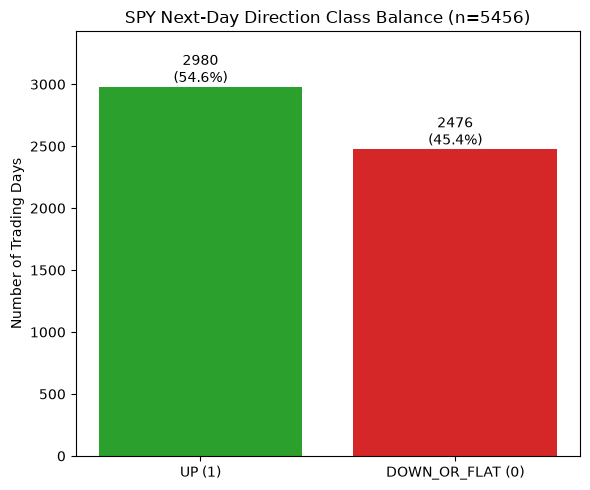

Saved figure to C:\Users\ayush\OneDrive\Desktop\Stock Time Movement Predictor\figures\class_balance.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["UP (1)", "DOWN_OR_FLAT (0)"]
counts = [overall_balance["n_up"], overall_balance["n_down_or_flat"]]
bars = ax.bar(labels, counts, color=["#2ca02c", "#d62728"])
ax.set_title(f"{config.SYMBOL} Next-Day Direction Class Balance (n={overall_balance['n_total']})")
ax.set_ylabel("Number of Trading Days")
ax.set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    pct = 100 * count / overall_balance["n_total"]
    ax.annotate(f"{count}\n({pct:.1f}%)", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
fig.tight_layout()

figure_path = config.FIGURES_DIR / "class_balance.png"
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to {figure_path}")

## 9. Chronological Train/Validation/Test Split

The oldest `TRAIN_RATIO` (70%) of rows form the training set, the next `VALIDATION_RATIO` (15%) form the validation set, and the remaining ~15% form the test set -- split strictly by chronological row order using the ratios already defined in `config.py`. **No shuffling, no random sampling, and no `sklearn.train_test_split` anywhere.** `train_df`, `validation_df`, and `test_df` were already computed in Section 8 (needed there for per-partition class balance); this section reports their exact date ranges and verifies the ordering guarantee.

In [11]:
def _report_partition(name, part_df, total_rows):
    pct = 100 * len(part_df) / total_rows
    print(f"{name}:")
    print(f"  First date: {part_df['Date'].min().date()}")
    print(f"  Last date:  {part_df['Date'].max().date()}")
    print(f"  Rows: {len(part_df)} ({pct:.2f}% of {total_rows})")
    print()

total_rows = len(target_df)
_report_partition("TRAIN", train_df, total_rows)
_report_partition("VALIDATION", validation_df, total_rows)
_report_partition("TEST", test_df, total_rows)

assert train_df["Date"].max() < validation_df["Date"].min(), "Train/validation date ranges overlap or are out of order."
assert validation_df["Date"].max() < test_df["Date"].min(), "Validation/test date ranges overlap or are out of order."
print("OK: train_end < validation_start and validation_end < test_start (strictly chronological, no overlap)."
)

TRAIN:
  First date: 2005-01-03
  Last date:  2020-03-05
  Rows: 3819 (70.00% of 5456)

VALIDATION:
  First date: 2020-03-06
  Last date:  2023-06-05
  Rows: 818 (14.99% of 5456)

TEST:
  First date: 2023-06-06
  Last date:  2026-09-10
  Rows: 819 (15.01% of 5456)

OK: train_end < validation_start and validation_end < test_start (strictly chronological, no overlap).


## 10. Baseline Models

_To be completed in Phase 5._ Two naive baselines, evaluated with zero model fitting:
1. **Persistence** — predict tomorrow's direction repeats today's direction.
2. **Majority-class** — always predict the class most frequent in the training partition.

## 11. Raw Feature Model

_To be completed in Phase 6._ Logistic Regression trained on raw/lagged OHLCV features only, with the scaler fit strictly on the training partition.

## 12. Technical Indicators

_To be completed in Phase 7._ At least three causally-computed indicators (e.g. moving averages, RSI, MACD, rolling volatility, returns) using the `ta` library or pandas — never `pandas-ta`.

## 13. Engineered Feature Model

_To be completed in Phase 8._ A second Logistic Regression model trained on the technical-indicator feature set, following the same chronological-split and scaler discipline as the raw model.

## 14. Time-Series Evaluation

_To be completed in Phase 9._ All four approaches evaluated on the identical, untouched, chronologically-final test window.

## 15. Four-Way Comparison

_To be completed in Phase 10._ Persistence vs. Majority vs. Raw Model vs. Engineered Model, compared on identical metrics and the identical test window.

## 16. Prediction Visualization

_To be completed in Phase 11._ Predicted vs. actual directional movement plotted across the test window.

## 17. Results

_To be completed._ No results exist yet — none will be reported here until they have actually been produced by executed code in this notebook.

## 18. Conclusions

_To be completed._

## 19. Limitations

_To be completed._ Expected discussion points: markets are largely efficient so directional accuracy near 50-55% is a normal and honest outcome, not a failure; single-instrument scope; no transaction costs or slippage modeled; raw (not dividend/split-adjusted) close prices used.

## 20. Reproducibility

All constants (symbol, date range, random seed, paths) are defined in `config.py`. Dependencies are pinned in `requirements.txt` for Python 3.12. Data is fetched reproducibly via `src/data_loader.py` rather than relying on an undocumented local file. No random shuffling is used anywhere in this notebook.

## 21. Environment Check

Quick sanity check that the environment and project modules are importable.

In [12]:
import matplotlib
import numpy as np
import pandas as pd
import sklearn

from src import baselines, data_loader, evaluation, features, models, preprocessing  # noqa: F401

print(f"pandas {pd.__version__}, numpy {np.__version__}, scikit-learn {sklearn.__version__}, matplotlib {matplotlib.__version__}")
print("All src modules imported successfully.")

pandas 3.0.5, numpy 2.5.3, scikit-learn 1.9.1, matplotlib 3.11.2
All src modules imported successfully.
